# Records and Tables

*Observation units, fields, and tabular representations.*

A record describes one observation through named fields. A table organizes records under a common set of fields.


## Records and Observation Units

- Observation unit: one student on one day within a single study week.
- Fields: `student_id`, `day`, `minutes`, `tasks`, `score`.
- Repeated student IDs can describe different observations.

`list[dict]` stores one dictionary per record. The outer list preserves record order.


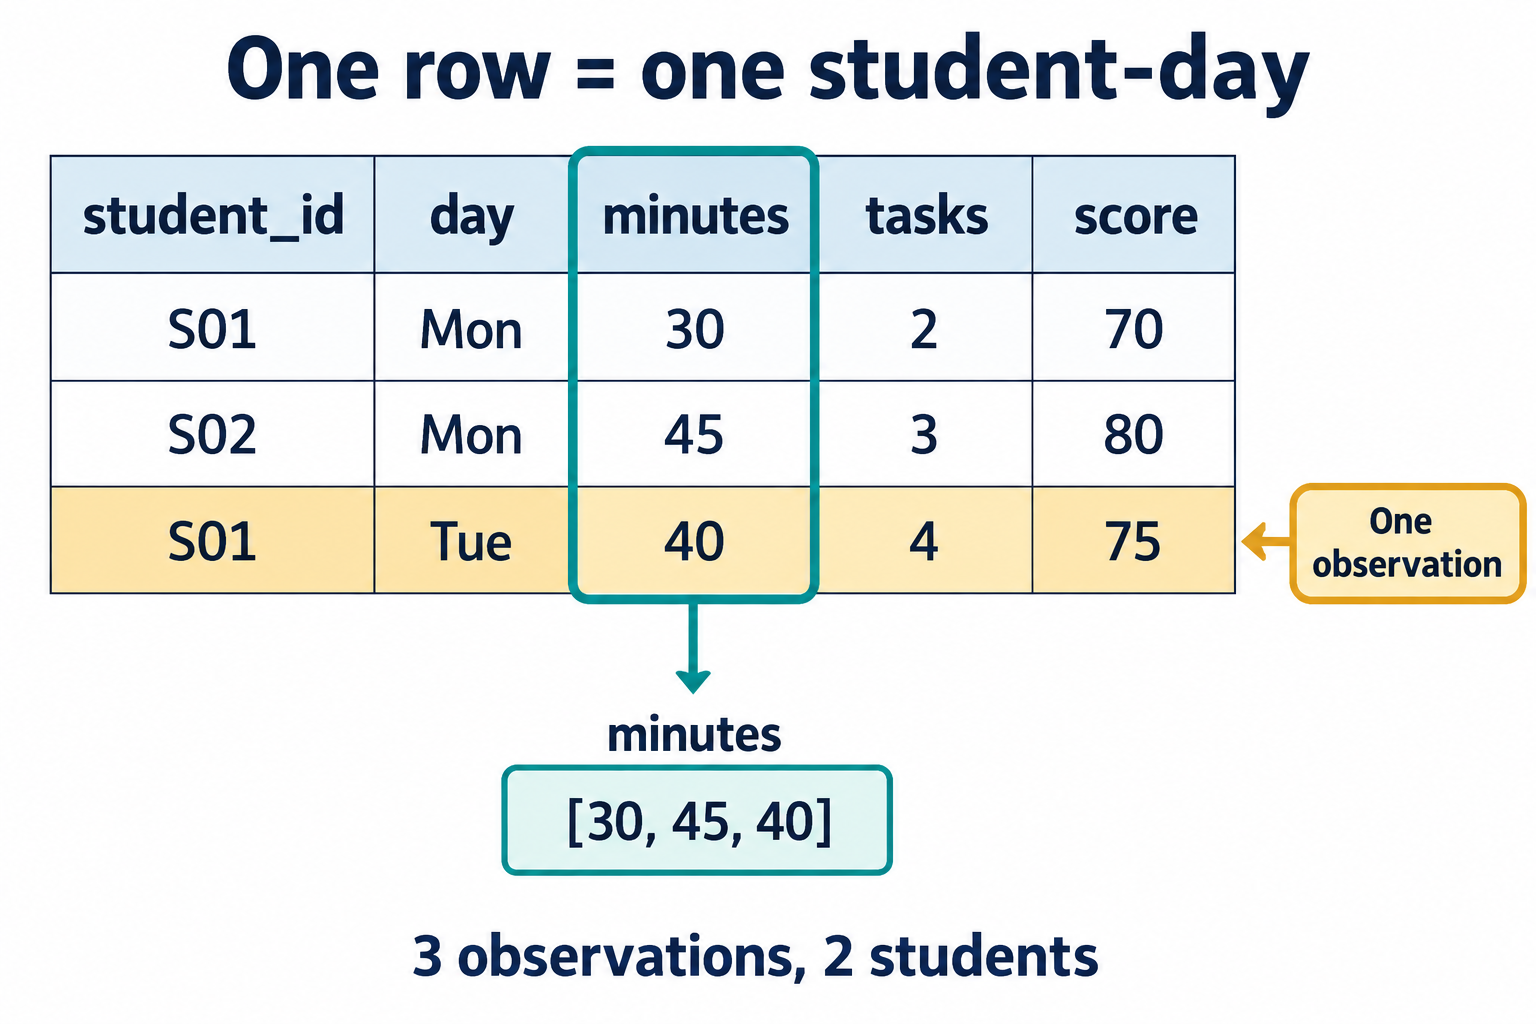

Three observations, two students. The `minutes` column contains `[30, 45, 40]`.


In [1]:
study_records = [
    {"student_id": "S01", "day": "Mon", "minutes": 30, "tasks": 2, "score": 70},
    {"student_id": "S02", "day": "Mon", "minutes": 45, "tasks": 3, "score": 80},
    {"student_id": "S01", "day": "Tue", "minutes": 40, "tasks": 4, "score": 75},
]

for record in study_records:
    print(record)

print("Observation count:", len(study_records))
print("First observation:", study_records[0])


{'student_id': 'S01', 'day': 'Mon', 'minutes': 30, 'tasks': 2, 'score': 70}
{'student_id': 'S02', 'day': 'Mon', 'minutes': 45, 'tasks': 3, 'score': 80}
{'student_id': 'S01', 'day': 'Tue', 'minutes': 40, 'tasks': 4, 'score': 75}
Observation count: 3
First observation: {'student_id': 'S01', 'day': 'Mon', 'minutes': 30, 'tasks': 2, 'score': 70}


`S01` contributes a Monday record and a Tuesday record. Three rows do not imply three distinct students.


## Row and Column Representations

| Representation | Outer container | First selection |
| --- | --- | --- |
| `list[dict]` | Ordered records | One observation |
| `dict[list]` | Named columns | One variable |

A comprehension collects one field across the records. All columns retain the same observation order and length.


In [2]:
study_columns = {
    "student_id": [record["student_id"] for record in study_records],
    "day": [record["day"] for record in study_records],
    "minutes": [record["minutes"] for record in study_records],
    "tasks": [record["tasks"] for record in study_records],
    "score": [record["score"] for record in study_records],
}

for field_name, values in study_columns.items():
    print(f"{field_name}: {values}")

print("Minutes through a record:", study_records[2]["minutes"])
print("Minutes through a column:", study_columns["minutes"][2])


student_id: ['S01', 'S02', 'S01']
day: ['Mon', 'Mon', 'Tue']
minutes: [30, 45, 40]
tasks: [2, 3, 4]
score: [70, 80, 75]
Minutes through a record: 40
Minutes through a column: 40


Both access paths return `40` for the third observation. The two containers represent the same table.


## Field Meaning and Missing Values

A **schema** specifies field names and expected value types. Field meaning determines which operations are meaningful.

| Field | Meaning | Representation |
| --- | --- | --- |
| `student_id` | Student identifier | String |
| `day` | Day label within this week | String |
| `minutes` | Study duration | Integer |
| `tasks` | Completed practice tasks | Integer |
| `score` | Assessment score | Integer, or `None` if unavailable |

`0` is an observed numeric value; `None` represents an unavailable value here. An additional record has zero study activity and an unavailable score.


In [3]:
incomplete_record = {
    "student_id": "S02",
    "day": "Tue",
    "minutes": 0,
    "tasks": 0,
    "score": None,
}

print("Study minutes:", incomplete_record["minutes"])
print("Completed tasks:", incomplete_record["tasks"])
print("Recorded score:", incomplete_record["score"])
print("Score is missing:", incomplete_record["score"] is None)


Study minutes: 0
Completed tasks: 0
Recorded score: None
Score is missing: True


Zero minutes and zero tasks are recorded values. The score is missing; it is not a score of zero.


Observation unit, field meaning, and row alignment define the table. These remain the same when the representation becomes a pandas DataFrame or a SQL table.
